<H1>Bayesian Linear Model -- TensorFlow Probability</H1>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
import tensorflow_probability as tfp

print('TF version:', tf.__version__)
print('TFP version:', tfp.__version__)

2025-08-27 22:22:51.573349: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-27 22:22:51.609493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.20.0
TFP version: 0.25.0


<H1>1) Data Generation</H1>

$\large\text{Create a training set that reprents the folowing linear function: }$<br>
$$\large y_{i}=2+3.25x_{i}+\epsilon_{i}\quad\quad\quad\text{ and }\epsilon\sim\mathcal{N}\left(0,\sigma^{2}I\right)$$

In [15]:
# Create and plot training data
# Set the desired slope
desired_slope = 3.25
# Set the desired intercept
desired_intercept = 2
# Set number of samples we want in our training data set
num_training_samples = 1000
x_train = np.linspace(-2, 2, num_training_samples)[:, np.newaxis]

x_train shape: (1000, 1)
y_train shape: (1000, 1)


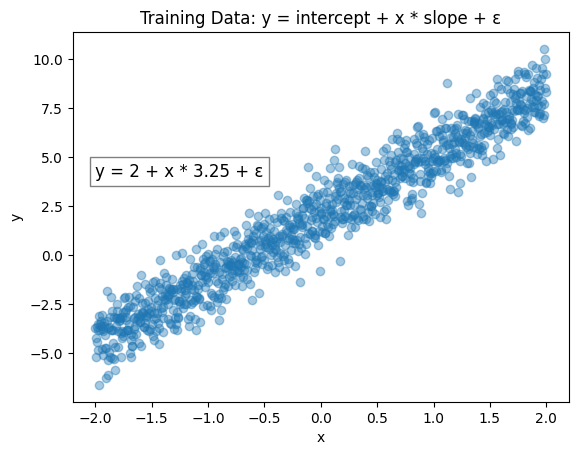

In [16]:
# Generate dependent variable y as a function of the training data x, the desired slope, and the desired intercept
#y_train = np.add(np.add(np.dot(x_train[:,1], desired_slope) ,desired_intercept), np.random.randn(num_training_samples))#[:, np.newaxis]
y_train = desired_intercept + x_train * desired_slope + np.random.randn(num_training_samples)[:, np.newaxis]
# Print the shape of x_train and y_train
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
# Plot the training data (ignoring the intercept term in each entry of x_train)
#plt.scatter(x_train[:,1], y_train, alpha=0.4)
plt.scatter(x_train, y_train, alpha=0.4)
plt.title('Training Data: y = intercept + x * slope + \u03B5')
plt.xlabel('x')
plt.ylabel('y')
plt.text(-2., 4, f'y = {desired_intercept} + x * {desired_slope} + \u03B5',
                       fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')) 
plt.show()


<H1>2) Consider the frequentist linear regression model</H1>

Let $n$ be the number of training samples and $m$ be the number of features in the training data.

$$\large\underset{\left(nx1\right)}{Y}=\begin{pmatrix}
y_{0} \\
y_{1} \\
\vdots \\
y_{n-1} \end{pmatrix}, 

\quad\underset{\left(nxm\right)}{X}=\left[\begin{matrix}
x_{0,0}=1 & x_{0,11} &\dots &x_{0,m-1} \\
x_{1,0}=1 & x_{1,1} &\dots &x_{1,m-1} \\
\vdots & \dots & \ddots & \vdots\\
x_{n-1,0}=1 & \dots & \dots &x_{N-1, m-1}
\end{matrix}\right],

\quad\underset{\left(Nx1\right)}{\epsilon}=\begin{pmatrix}
\epsilon_{0} \\
\epsilon_{1} \\
\vdots \\
\epsilon_{n-1} \end{pmatrix}
\text{where }\epsilon\sim\mathcal{N}\left(0, \sigma^{2}I\right)$$

$$\large\beta=\begin{pmatrix}
\beta_{0} \\
\beta_{1} \\
\vdots \\
\beta_{m} \end{pmatrix} \large\quad\text{and }\beta_{i}\sim\mathcal{N}\left(\mu_{i}, \sigma_{i}^{2}\right)$$


$$\large\mathbb{E}\left[Y\right]=X\hat{\beta}$$
$$\large\hat{\beta}\sim\mathcal{...}(...)$$

$$\large\quad\underset{\left(nx1\right)}{\epsilon}=\begin{pmatrix}
\epsilon_{0} \\
\epsilon_{1} \\
\vdots \\
\epsilon_{n-1} \end{pmatrix}
\text{where }\epsilon_{i}\sim\mathcal{N}\left(\mu_{error}, \sigma_{error}^{2}\right)\text{ for }\forall i\in\left[0,n\right]$$

$$\large\hat{Y}\sim\mathcal{N}(\hat{\beta} X, \hat{\sigma}^{2}I)$$


$P(Y_{i}=y_{i}|X_{i}=x_{i}, \beta=\hat{\beta}, \sigma=\hat{\sigma}^{2})$<br>

$\large\text{Computing }\left(X^{T}X\right)^{-1}\text{becomes a limiting factor in scaling the algorithm to large data sets.}$<br>


<H1>3) Configure the Bayesian regression model</H1>

$$\large P(\beta|\sigma, y)\sim\mathcal{...}\left(...\right)$$

$$P\left(\sigma^{2}|y\right) = \frac{P\left(\beta, \sigma^{2}|y\right)}{P\left(\beta,\sigma^{2}|y\right)}$$

$$\large P\left(\sigma^{2} | y \right) \sim\text{...}$$

In [5]:
# Set the input shape
input_shape = x_train.shape[1]
print('Input shape:', input_shape)
# Create a dense Keras model along with a distribution layer that outputs a normal 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=2, input_shape=(x_train.shape[1],), activation='linear'),
    tfp.layers.DistributionLambda(lambda t: tfp.distributions.Independent(tfp.distributions.Normal(loc=t[..., :1], scale=tf.math.softplus(t[..., 1:]))),
        convert_to_tensor_fn=tfp.distributions.Distribution.sample)
])

Input shape: 1
Instructions for updating:
Please pass an integer value for `reinterpreted_batch_ndims`. The current behavior corresponds to `reinterpreted_batch_ndims=tf.size(distribution.batch_shape_tensor()) - 1`.


I0000 00:00:1756333373.355190  142045 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1190 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:02:00.0, compute capability: 8.6


$\large\quad\text{Define the loss function}$<br>

Minimizing the negative log-likelihood of the learned distribution 

In [6]:
# Define the negative log likelihood cost function
def nll(x_train, distribution):
    return -tf.reduce_sum(distribution.log_prob(x_train))

In [7]:
# Instantiate an optimizer
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.005)
model.compile(loss=nll, optimizer=optimizer)
model.summary()
# model.fit(x_train, y_train, epochs=500, verbose=False)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 4         
                                                                 
 distribution_lambda (Distr  ((None, 1),               0         
 ibutionLambda)               (None, 1))                         
                                                                 
Total params: 4 (16.00 Byte)
Trainable params: 4 (16.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
# Train model, record weights after each epoch
epochs = [0]
training_weights = [model.weights[0].numpy()[0, 0]]
training_bias = [model.weights[1].numpy()[0]]
# Loop over epochs
for epoch in range(100):
    # Get a fit on the training data
    model.fit(x=x_train, y=y_train, epochs=1, verbose=False)
    # Append the current epoch to the epochs list
    epochs.append(epoch)
    # Append the current weight to the training_weights list
    training_weights.append(model.weights[0].numpy()[0, 0])
    # Append the current bais to the training_bias list
    training_bias.append(model.weights[1].numpy()[0])

2025-08-27 22:22:54.363621: I external/local_xla/xla/service/service.cc:163] XLA service 0x7336b5d77fd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-27 22:22:54.363633: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-08-27 22:22:54.367751: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-27 22:22:54.374325: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90701
I0000 00:00:1756333374.403593  142209 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_142045/1091908033.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_train, y_hat, color='red', alpha=0.8, label='model $\mu$')
/tmp/ipykernel_142045/1091908033.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_train, y_hat_m2sd, color='green', alpha=0.8, label='model $\mu \pm 2 \sigma$')


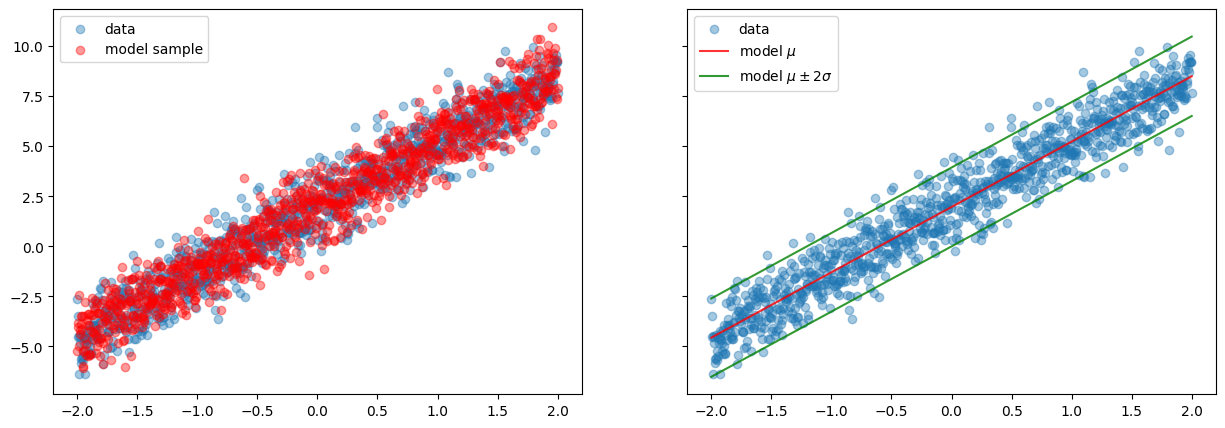

In [9]:
# Plot the data and a sample from the model
y_model = model(x_train)
y_sample = y_model.sample()
y_hat = y_model.mean()
y_sd = y_model.stddev()
y_hat_m2sd = y_hat - 2 * y_sd
y_hat_p2sd = y_hat + 2 * y_sd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax1.scatter(x_train, y_train, alpha=0.4, label='data')
ax1.scatter(x_train, y_sample, alpha=0.4, color='red', label='model sample')
ax1.legend()
ax2.scatter(x_train, y_train, alpha=0.4, label='data')
ax2.plot(x_train, y_hat, color='red', alpha=0.8, label='model $\mu$')
ax2.plot(x_train, y_hat_m2sd, color='green', alpha=0.8, label='model $\mu \pm 2 \sigma$')
ax2.plot(x_train, y_hat_p2sd, color='green', alpha=0.8)
ax2.legend()
plt.show()

<H1>4) Make predictions on the training data.</H1>

In [10]:
# Make predictions.
yhat = model(x_train)
yhat_mean = yhat.mean()
yhat_std = yhat.stddev()

<H1>5) Compute trained prediction model metrics.</H1>

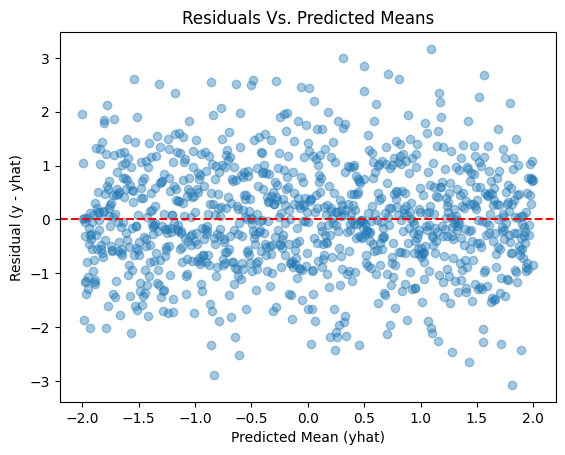

In [11]:
# Plot the residuals
residuals = y_train - yhat_mean
plt.scatter(x_train, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Vs. Predicted Means')
plt.xlabel('Predicted Mean (yhat)')
plt.ylabel('Residual (y - yhat)')
plt.show()

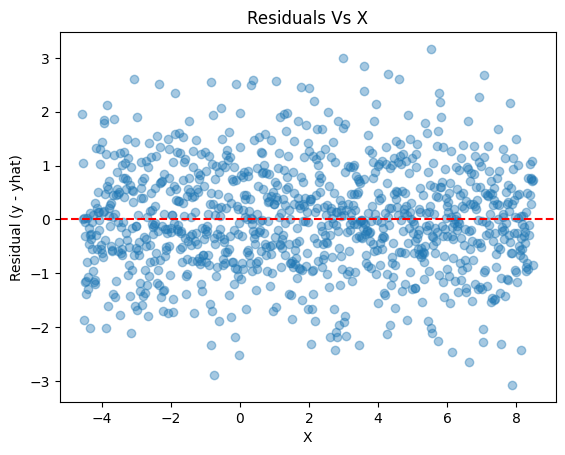

In [12]:
# Scatter Plot residuals vs predicitons
# Plot the residuals
residuals = y_train - yhat_mean
plt.scatter(yhat_mean, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Vs X')
plt.xlabel('X')
plt.ylabel('Residual (y - yhat)')
plt.show()

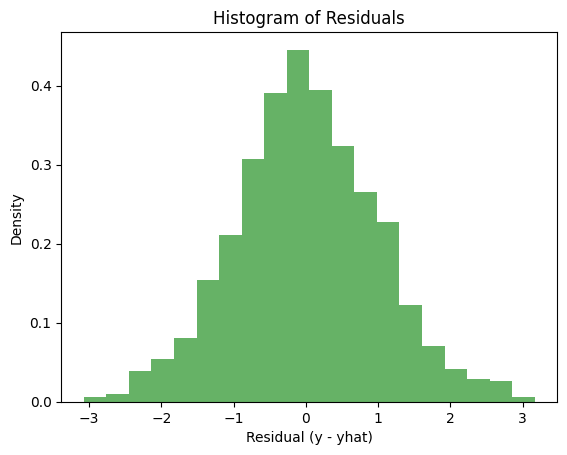

In [13]:
# Plot historgram of residuals
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='green')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (y - yhat)')
plt.ylabel('Density')
plt.show()  

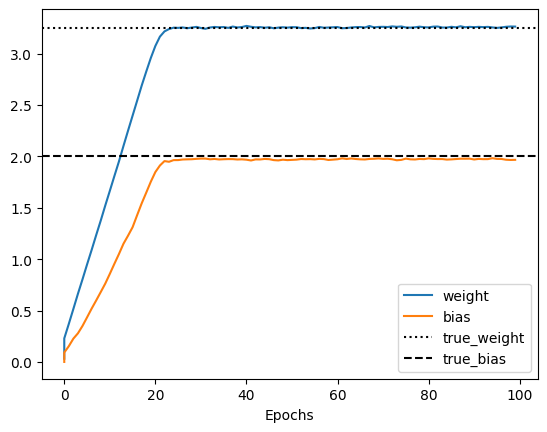

In [14]:
# Plot the model weights as they train, converging to the correct values
plt.plot(epochs, training_weights, label='weight')
plt.plot(epochs, training_bias, label='bias')
plt.axhline(y=3.25, label='true_weight', color='k', linestyle=':')
plt.axhline(y=2, label='true_bias', color='k', linestyle='--')
plt.xlabel('Epochs')
plt.legend()
plt.show()

<H1>References</H1>

1. Kutner M., Nachtsheim C., Neter J., "Applied Linear Regression Models", McGraw3-Hill Irwin, 4th ed, 2004.
2. Gelman A., Carlin J., Stern H., Dunson D., Vehtari A., Rubin D., "Bayesian Data Analysis", CRC Press, Boca Raton FL, 3rd ed., 2014.